Importing

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

loading csv

In [37]:
df = pd.read_csv("data/nigeria.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


create column "Country"

In [38]:
df["Country"]="nigeria"

changing date

In [39]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Date"].head()

0   2015-01-01
1   2015-01-02
2   2015-01-03
3   2015-01-04
4   2015-01-05
Name: Date, dtype: datetime64[us]

change month to name

In [40]:

df["Month_Name"] = df["Date"].dt.month_name()

replace -999 with Nan if exist

In [41]:
df = df.replace(-999, np.nan, inplace=True)

check for duplicate row and return how many

In [42]:
df.duplicated().sum()

np.int64(0)


The dataset was checked for duplicate rows using df.duplicated().sum(). The result showed 0 duplicate rows, indicating that all observations are unique. 
Therefore, no rows were removed during the deduplication step.

In [43]:
df = df.drop_duplicates()

describe 

In [44]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN


The dataset contains 4,108 observations from 2015 to 2026 with no missing values, indicating high data quality. The average temperature (T2M) is 26.66°C, ranging from 21.12°C to 29.29°C, showing a consistently warm and stable climate with low variability. The daily temperature range averages 4.03°C, suggesting relatively small differences between day and night temperatures. Precipitation (PRECTOTCORR) has a mean of 4.21 mm but reaches up to 166.1 mm, indicating a strongly right-skewed distribution with occasional extreme rainfall events. Humidity (RH2M) is high (mean ≈ 85.2%), reflecting very moist atmospheric conditions. Wind speeds are generally low to moderate, while surface pressure (PS) remains stable with minimal variation. Overall, the dataset represents a warm, humid, and stable climate with irregular but sometimes intense rainfall, and it is well-suited for further analysis due to its completeness.

number of Nan

In [45]:
df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month_Name     0.0
dtype: float64

MIssing value >5%

In [46]:
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month_Name     0.0
dtype: float64

The percentage of missing values was computed for all columns. The results show that all variables have 0.0% missing values. 
No column exceeds the 5% threshold, indicating that the dataset is complete and suitable for analysis without requiring imputation or removal of variables.

identify outlier using z-score

In [47]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

In [48]:
z_scores = np.abs(stats.zscore(df[cols]))

In [49]:
outliers_mask=(z_scores>3).any(axis=1)

In [50]:
print(f"\nRows flagged as outliers: {outliers_mask.sum()}")


Rows flagged as outliers: 225


Z-score analysis was performed on key climate variables (T2M, T2M_MAX, T2M_MIN, PRECTOTCORR, RH2M, WS2M, WS2M_MAX) using a threshold of |Z| > 3 to detect extreme values. The analysis identified 225 rows as outliers, indicating a relatively high number of extreme observations in the dataset. These outliers are mainly associated with precipitation, wind speed, and occasional temperature or humidity extremes, which are typically more variable in climate datasets. While some of these values may represent genuine extreme weather events, the higher count suggests increased variability or more frequent extreme conditions in the data. It is recommended to retain these observations for climate analysis, but apply robust techniques such as log transformation, winsorization, or scaling to minimize their impact on statistical models and ensure more stable results.

Handling missing values

In [51]:
threshold = int(0.3 * len(df.columns))

df = df[df.isna().sum(axis=1) <= threshold]


Forward-fill weather variables

In [52]:
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
df[weather_cols] = df[weather_cols].ffill()
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month_Name     0
dtype: int64

cleaned

In [53]:
df_clean = df[~outliers_mask].copy()

In [54]:
print(f"Cleaned rows:{len(df)}")

Cleaned rows:4108


In [55]:
df.to_csv("data/nigeria_clean.csv", index=False)

In [56]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

In [57]:
print(df_clean.columns)

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Date',
       'Month_Name'],
      dtype='str')


In [58]:
for col in df.columns:
    print(repr(col))


'YEAR'
'DOY'
'T2M'
'T2M_MAX'
'T2M_MIN'
'T2M_RANGE'
'PRECTOTCORR'
'RH2M'
'WS2M'
'WS2M_MAX'
'PS'
'QV2M'
'Country'
'Date'
'Month_Name'


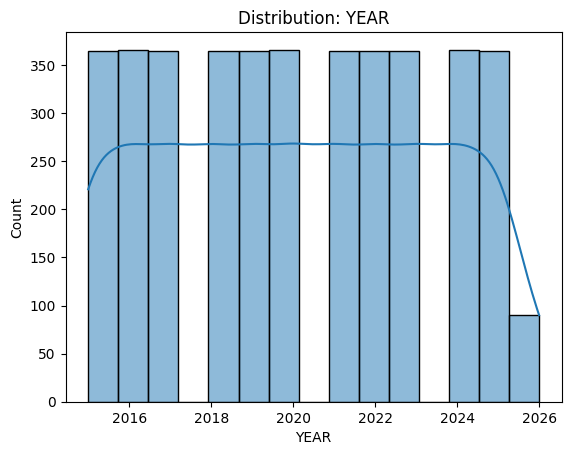

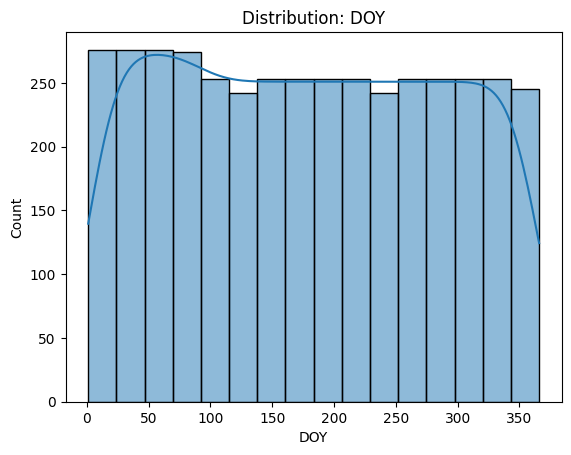

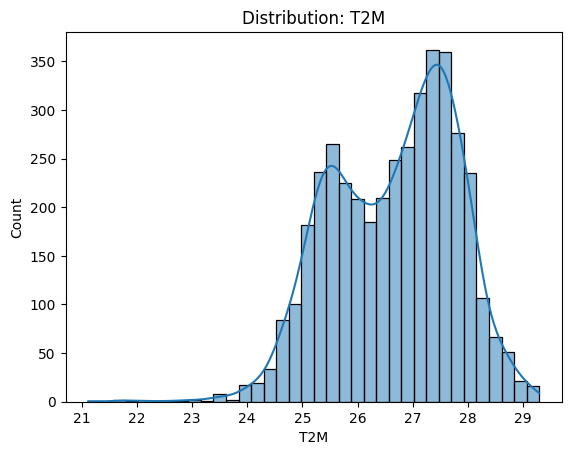

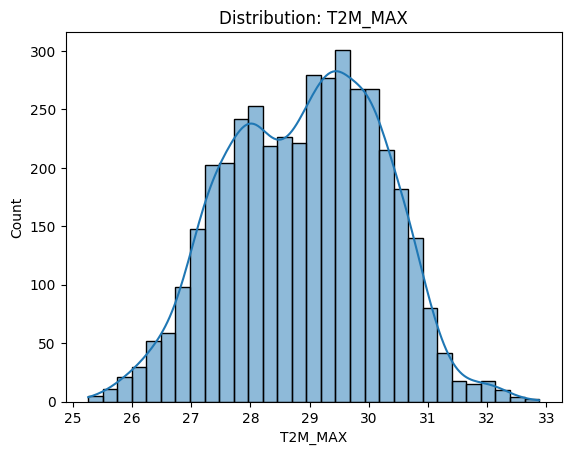

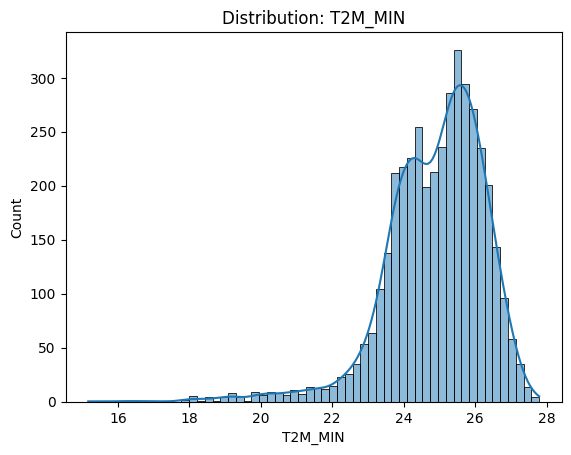

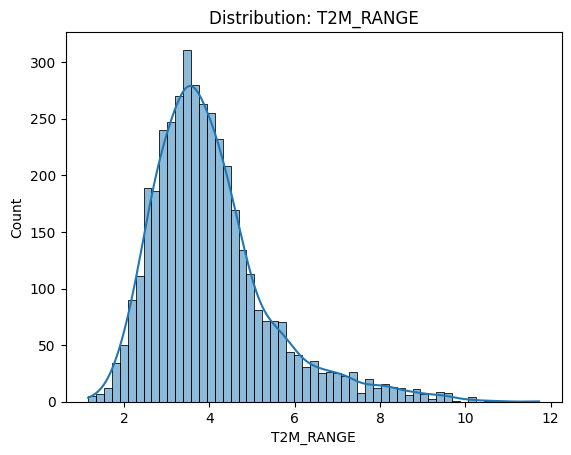

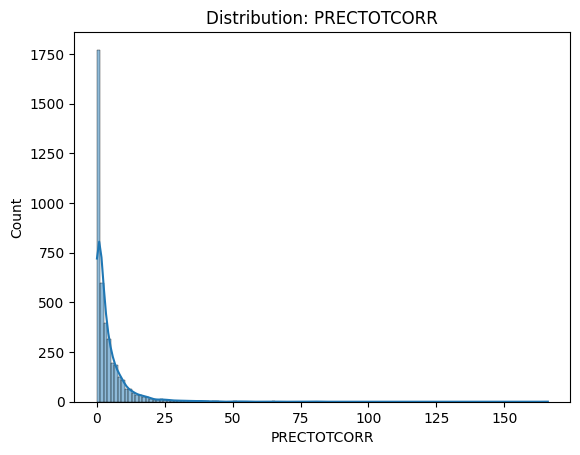

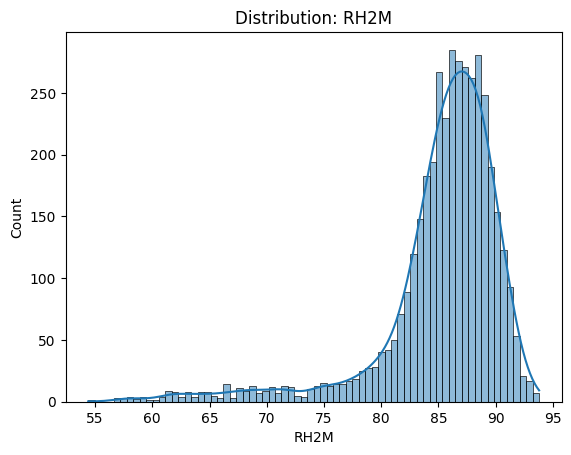

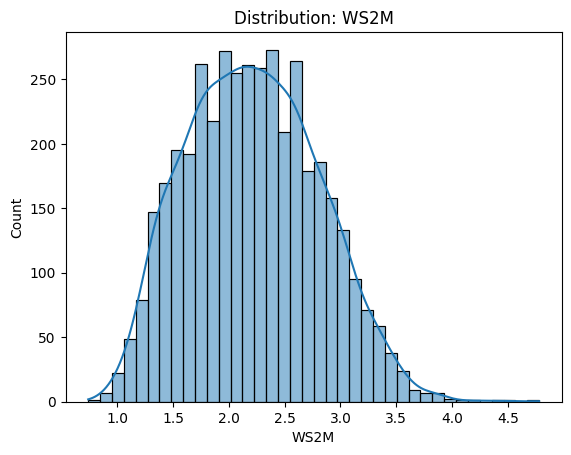

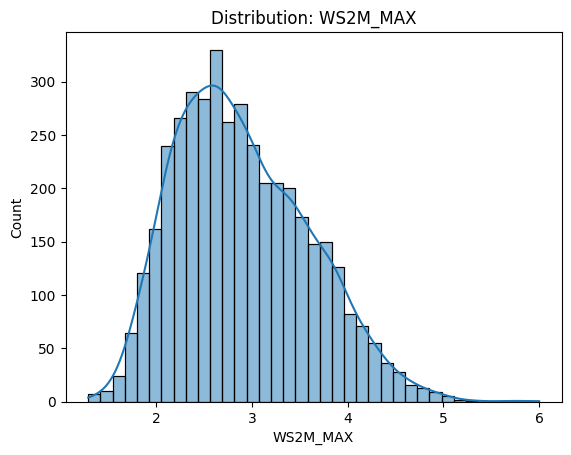

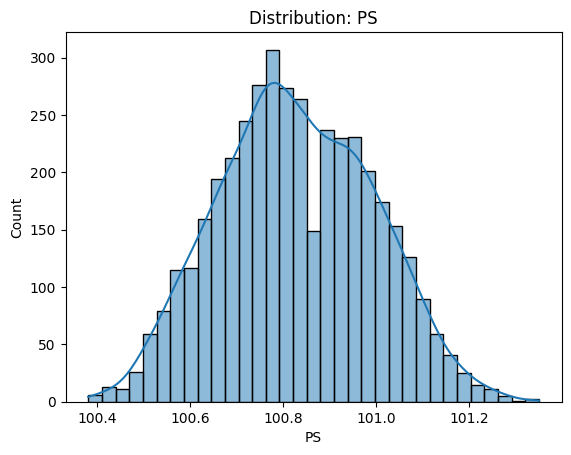

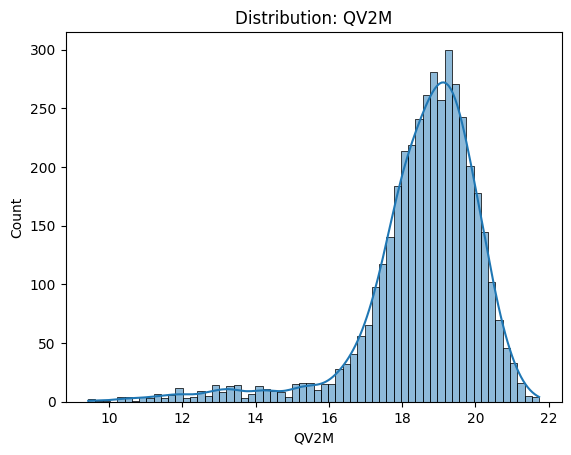

In [59]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    plt.figure()
    sns.histplot(df[c], kde=True)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.show()

In [60]:

df_clean = df[~outliers_mask].copy()

Monthly average T2M

In [61]:

# Set Date as index for resampling
df_clean = df_clean.set_index("Date")

In [62]:

monthly_t2m = df_clean["T2M"].resample("ME").mean()

Find warmest and coolest months

In [63]:

warmest_month = monthly_t2m.idxmax()
coolest_month = monthly_t2m.idxmin()
warmest_value = monthly_t2m.max()
coolest_value = monthly_t2m.min()


plot

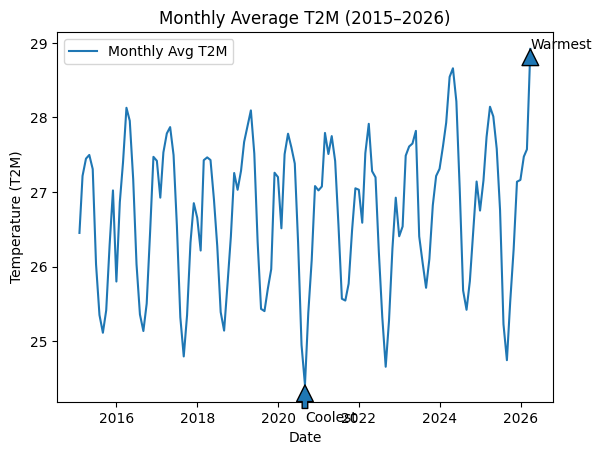

In [64]:
# Plot
plt.plot(monthly_t2m, label="Monthly Avg T2M")
# Annotate warmest month
plt.annotate("Warmest",
             xy=(warmest_month, warmest_value),
             xytext=(warmest_month, warmest_value),
             arrowprops=dict())

# Annotate coolest month
plt.annotate("Coolest",
             xy=(coolest_month, coolest_value),
             xytext=(coolest_month, coolest_value - 0.5),
             arrowprops=dict())

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()

BAR chart for PRECTOTCORR

In [65]:
print(df_clean.head())

            YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  \
Date                                                                            
2015-01-02  2015    2  26.16    29.41    22.87       6.54         0.00  73.23   
2015-01-03  2015    3  25.66    29.02    22.63       6.39         0.00  78.71   
2015-01-17  2015   17  25.03    29.31    21.53       7.78         0.02  83.19   
2015-01-18  2015   18  25.52    29.18    22.74       6.44         0.03  87.20   
2015-01-19  2015   19  25.94    29.32    23.38       5.94         0.21  87.45   

            WS2M  WS2M_MAX      PS   QV2M  Country Month_Name  
Date                                                           
2015-01-02  1.42      1.95  100.94  15.37  nigeria    January  
2015-01-03  1.69      2.33  101.06  15.98  nigeria    January  
2015-01-17  1.31      1.95  100.99  16.17  nigeria    January  
2015-01-18  1.88      2.16  101.01  17.56  nigeria    January  
2015-01-19  2.25      3.03  100.90  18.11  niger

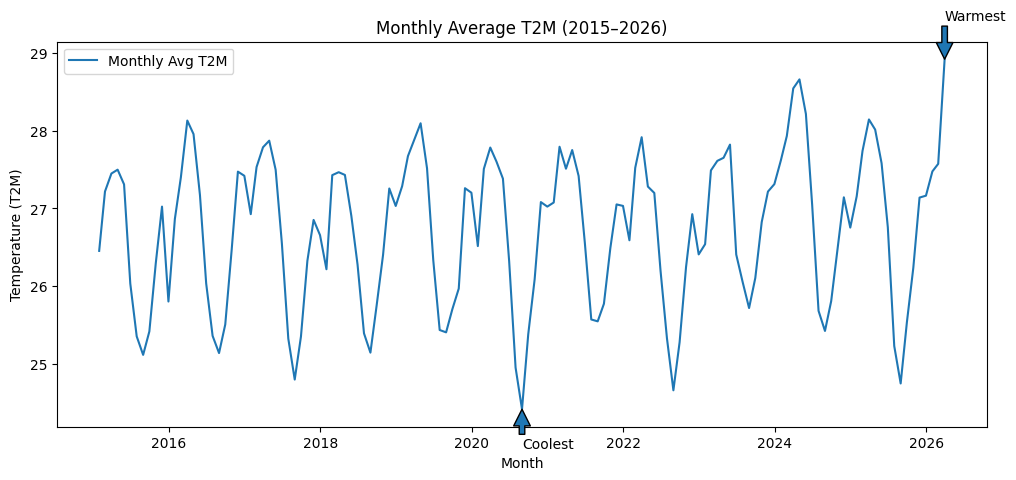

In [66]:


# Find warmest and coolest months
warmest_date = monthly_t2m.idxmax()
coolest_date = monthly_t2m.idxmin()

warmest_value = monthly_t2m.max()
coolest_value = monthly_t2m.min()

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_t2m, label="Monthly Avg T2M")

# Annotate warmest month
plt.annotate("Warmest",
             xy=(warmest_date, warmest_value),
             xytext=(warmest_date, warmest_value + 0.5),
             arrowprops=dict())

# Annotate coolest month
plt.annotate("Coolest",
             xy=(coolest_date, coolest_value),
             xytext=(coolest_date, coolest_value - 0.5),
             arrowprops=dict())

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()


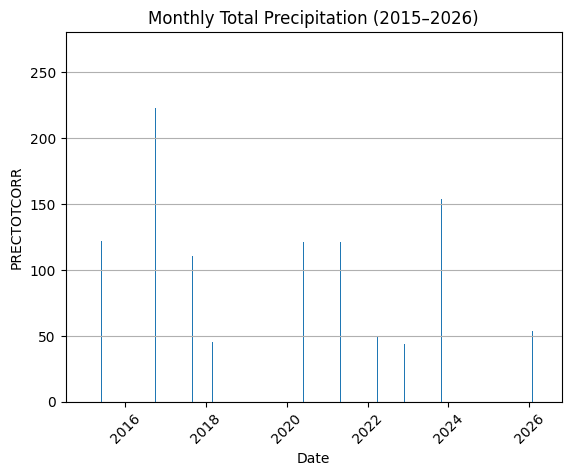

In [67]:
# Monthly average T2M
monthly_precip = df_clean["PRECTOTCORR"].resample("ME").sum()
plt.bar(monthly_precip.index, monthly_precip.values)
plt.title("Monthly Total Precipitation (2015–2026)")
plt.xlabel("Date")
plt.ylabel("PRECTOTCORR")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

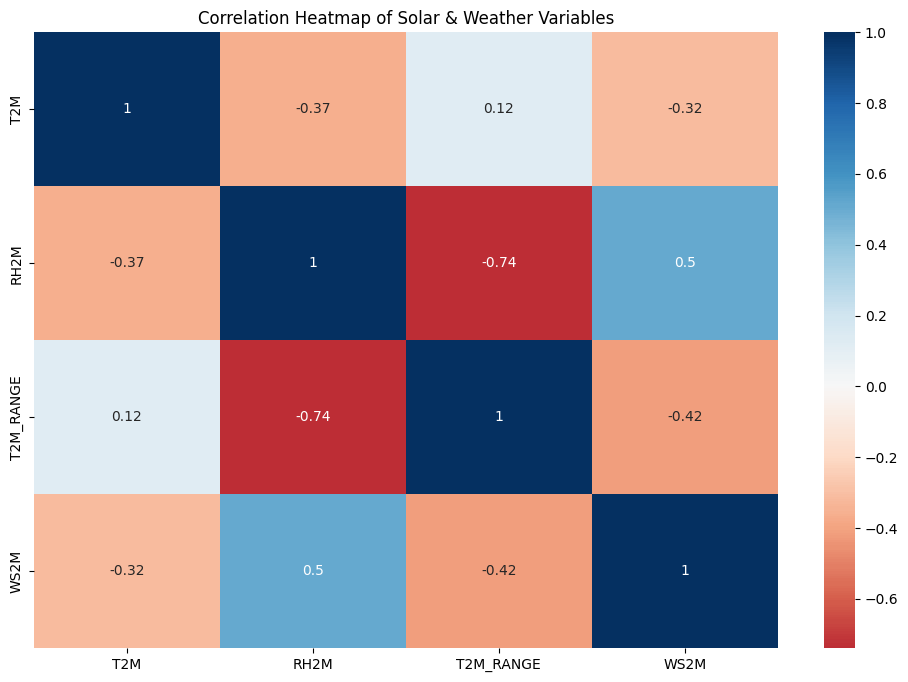

In [68]:

#selecting main columns for correlation
corr_cols = ['T2M', 'RH2M', 'T2M_RANGE', 'WS2M']
correlation_matrix = df_clean[corr_cols].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', center=0)
plt.title('Correlation Heatmap of Solar & Weather Variables')
plt.show()

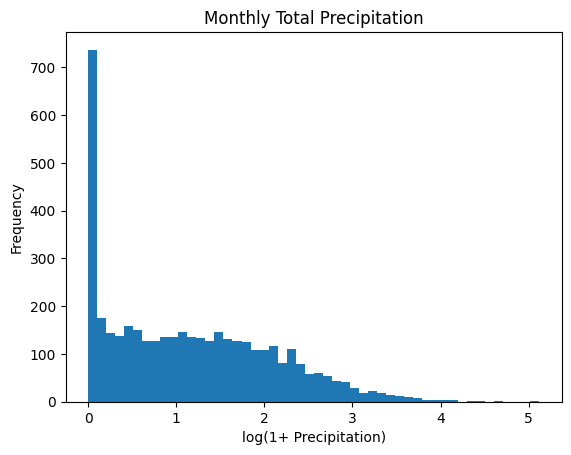

In [69]:


plt.hist(np.log1p(df["PRECTOTCORR"].dropna()), bins=50)
plt.title("Monthly Total Precipitation")
plt.xlabel("log(1+ Precipitation)")
plt.ylabel("Frequency")
plt.show()

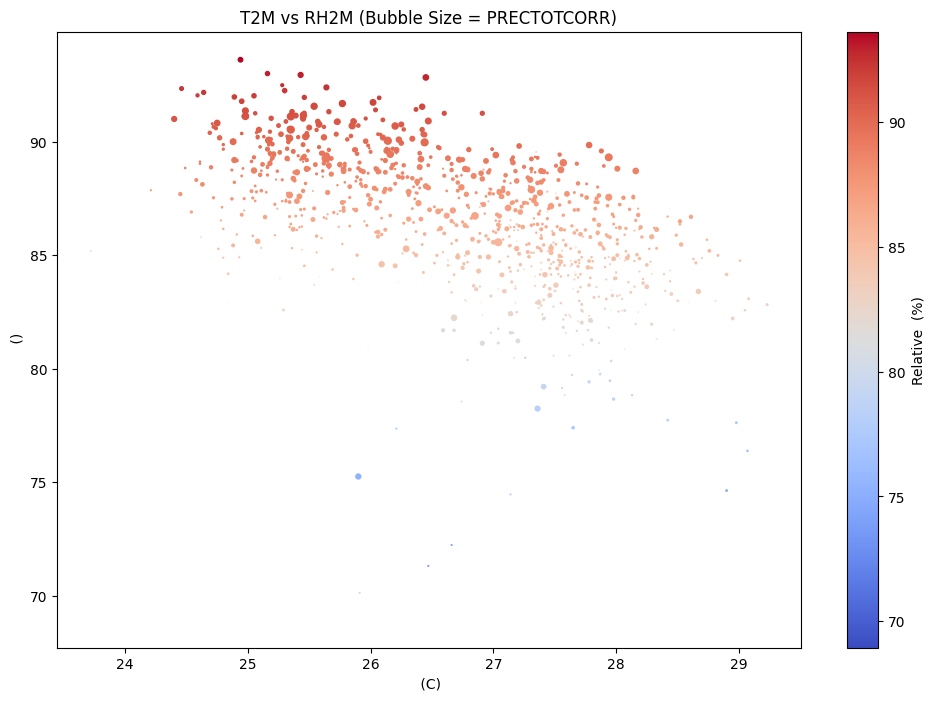

In [70]:
# Select a small random sample (e.g., 1000 rows) so the bubbles aren't too crowded
sample_bubble = df_clean.sample(1000)

plt.figure(figsize=(12, 8))
plt.scatter(sample_bubble['T2M'], sample_bubble['RH2M'], 
            s=sample_bubble['PRECTOTCORR'], # Size of bubble
            c=sample_bubble['RH2M'], # Color can also 
            cmap='coolwarm')

plt.title('T2M vs RH2M (Bubble Size = PRECTOTCORR)')
plt.xlabel(' (C)')
plt.ylabel(' ()')
plt.colorbar(label='Relative  (%)')
plt.show()
